# Global-normalized WSI tiling versus medium-mode tiling

This is a separately gated comparison on a centered crop covering approximately one half of the source height and width. The new global-normalized WSI method and the mIF-pipeline-style eval_medium_image() call use the same selected-channel crop and identical InstanSeg postprocessing. The medium call intentionally retains the pipeline's normal eval_medium_image() normalization and native-grid output rescaling; the report records this because the normalization transforms are not identical. Nucleus/cell resolution is deliberately disabled for this comparison. No watershed or other reconciliation is run here.

In [1]:
from pathlib import Path
from collections import defaultdict
import gc
import json
import time
import xml.etree.ElementTree as ET

import numpy as np
import tifffile
import torch
import zarr

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = REPO_ROOT.parent
PIPELINE_SRC = REPO_ROOT / 'src'
INSTANSEG_ROOT = (REPO_ROOT.parent / 'instanseg').resolve()
if not (INSTANSEG_ROOT / 'instanseg/inference_class.py').exists():
    raise FileNotFoundError(INSTANSEG_ROOT)
import sys
sys.path.insert(0, str(PIPELINE_SRC))
sys.path.insert(0, str(INSTANSEG_ROOT))
from instanseg import InstanSeg
from tiffslide import TiffSlide
from mif_pipeline.instanseg_runner import _read_selected_full_merge_channels
import instanseg.inference_class as instanseg_inference_class
instanseg_inference_class.TiffSlide = TiffSlide

print({
    'python': sys.executable,
    'instanseg_root': str(INSTANSEG_ROOT),
    'pipeline_src': str(PIPELINE_SRC),
    'cuda': torch.cuda.is_available(),
})

{'python': '/data1/lowes/ratnayn/conda_envs/instanseg_training/bin/python', 'instanseg_root': '/data1/lowes/ratnayn/Codex/projects/instanseg', 'pipeline_src': '/data1/lowes/ratnayn/Codex/projects/mIF-pipeline/src', 'cuda': True}


In [2]:
SLIDE_ID = 'SLIDE-0330'
FULL_MERGE_OME = Path(
    '/data1/lowes/ratnayn/Data/CellDive_analysis_data/image_data/'
    'SLIDE-0330/outputs_v3/SLIDE-0330_full_merge.ome.tif'
)
SCRATCH_ROOT = Path('/data1/lowes/ratnayn/Codex/codex-scratch/mIF-pipeline')
OUTPUT_DIR = SCRATCH_ROOT / 'instanseg_wsi_vs_medium_half_crop' / SLIDE_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEGMENTATION_CHANNELS = [
    'R1_DAPI', 'R4_P19_POLYRAT', 'R4_GFP_POLY_AF488',
    'R6_CD45_CST_AF647', 'R6_PANCK_AE1_AE3_750',
    'R12_CD31_D8V9E_AF750', 'R7_NAK_ATPASE_555',
    'R8_F480_D2S9R_555', 'R9_CD68_E3O7V_488',
    'R12_CD3E_E4T1B_AF555',
]
PIXEL_SIZE_UM = 0.325
MODEL_NAME = 'fluorescence_nuclei_and_cells'
WSI_TILE_SIZE = 2048
WSI_OVERLAP = 80
WSI_DETECTION_SIZE = 20
WSI_BATCH_SIZE = 1
MEDIUM_BATCH_SIZE = 1
NORMALIZATION_PERCENTILES = (0.1, 99.9)
CROP_FRACTION = 0.5
CROP_IO_TILE = 512
INSTANCE_MATCH_FRACTION = 0.5
INSTANCE_LINK_FRACTION = 0.2
SEAM_BAND_NATIVE_PIXELS = 20
OVERWRITE = False
RUN_BUILD_CROP = True
RUN_WSI_INFERENCE = True
RUN_MEDIUM_INFERENCE = True

EVAL_KWARGS = {
    'min_size': 10,
    'mask_threshold': 0.53,
    'peak_distance': 5,
    'seed_threshold': 0.7,
    'overlap_threshold': 0.3,
    'mean_threshold': 0.0,
    'fg_threshold': 0.5,
    'window_size': 32,
    'cleanup_fragments': True,
    'resolve_cell_and_nucleus': False,
}

with tifffile.TiffFile(FULL_MERGE_OME) as handle:
    series = handle.series[0]
    source_shape = tuple(int(value) for value in series.shape)
    ome_root = ET.fromstring(handle.ome_metadata)
    source_names = [
        element.attrib.get('Name')
        for element in ome_root.iter()
        if element.tag.endswith('Channel') and element.attrib.get('Name')
    ]

source_height, source_width = source_shape[-2:]
channel_to_index = {name: index for index, name in enumerate(source_names)}
missing = [name for name in SEGMENTATION_CHANNELS if name not in channel_to_index]
if missing:
    raise ValueError(f'Missing source channels: {missing}')
SOURCE_CHANNEL_IDS = [channel_to_index[name] for name in SEGMENTATION_CHANNELS]
CROP_CHANNEL_IDS = list(range(len(SOURCE_CHANNEL_IDS)))

CROP_HEIGHT = max(16, int(source_height * CROP_FRACTION) // 16 * 16)
CROP_WIDTH = max(16, int(source_width * CROP_FRACTION) // 16 * 16)
CROP_Y = ((source_height - CROP_HEIGHT) // 2) // 16 * 16
CROP_X = ((source_width - CROP_WIDTH) // 2) // 16 * 16

CROP_OME = OUTPUT_DIR / f'{SLIDE_ID}_selected_half_crop.ome.tif'
CROP_BUFFER = OUTPUT_DIR / f'{SLIDE_ID}_crop_channel_buffer.uint16.dat'
WSI_ZARR = OUTPUT_DIR / f'{SLIDE_ID}_global_wsi.zarr'
MEDIUM_ZARR = OUTPUT_DIR / f'{SLIDE_ID}_medium.zarr'
COMPARISON_JSON = OUTPUT_DIR / f'{SLIDE_ID}_wsi_vs_medium_comparison.json'

print({
    'source_shape': source_shape,
    'selected_source_channel_ids': SOURCE_CHANNEL_IDS,
    'crop_xy': (CROP_X, CROP_Y),
    'crop_shape_yx': (CROP_HEIGHT, CROP_WIDTH),
    'crop_fraction_each_axis': CROP_FRACTION,
    'medium_input_ram_gib': len(CROP_CHANNEL_IDS) * CROP_HEIGHT * CROP_WIDTH * 4 / 2**30,
    'crop_buffer_disk_gib': CROP_HEIGHT * CROP_WIDTH * 2 / 2**30,
    'medium_loader': 'mif_pipeline.instanseg_runner._read_selected_full_merge_channels',
    'medium_input_disk_backed': False,
    'eval_kwargs': EVAL_KWARGS,
})

{'source_shape': (72, 55388, 62688), 'selected_source_channel_ids': [4, 38, 42, 51, 52, 17, 56, 62, 71, 15], 'crop_xy': (15664, 13840), 'crop_shape_yx': (27680, 31344), 'crop_fraction_each_axis': 0.5, 'medium_input_ram_gib': 32.3206901550293, 'crop_buffer_disk_gib': 1.6160345077514648, 'medium_loader': 'mif_pipeline.instanseg_runner._read_selected_full_merge_channels', 'medium_input_disk_backed': False, 'eval_kwargs': {'min_size': 10, 'mask_threshold': 0.53, 'peak_distance': 5, 'seed_threshold': 0.7, 'overlap_threshold': 0.3, 'mean_threshold': 0.0, 'fg_threshold': 0.5, 'window_size': 32, 'cleanup_fragments': True, 'resolve_cell_and_nucleus': False}}


In [3]:
def selected_crop_pages():
    # Use tifffile's source-level Zarr store so each chunk reads only one
    # requested source channel. TiffSlide.read_region() can decode all 72
    # channels for every small region, which made the previous builder
    # appear hung before the first TIFF page was yielded.
    with tifffile.TiffFile(str(FULL_MERGE_OME)) as handle:
        source_store = handle.series[0].aszarr(level=0)
        source = zarr.open(source_store, mode='r')
        page_buffer = np.memmap(
            CROP_BUFFER, mode='w+', dtype=np.uint16,
            shape=(CROP_HEIGHT, CROP_WIDTH),
        )
        try:
            for source_channel_id in SOURCE_CHANNEL_IDS:
                for y0 in range(0, CROP_HEIGHT, CROP_IO_TILE):
                    y1 = min(CROP_HEIGHT, y0 + CROP_IO_TILE)
                    for x0 in range(0, CROP_WIDTH, CROP_IO_TILE):
                        x1 = min(CROP_WIDTH, x0 + CROP_IO_TILE)
                        block = np.asarray(source.oindex[
                            [source_channel_id],
                            slice(CROP_Y + y0, CROP_Y + y1),
                            slice(CROP_X + x0, CROP_X + x1),
                        ])[0]
                        page_buffer[y0:y1, x0:x1] = block
                page_buffer.flush()
                yield page_buffer
        finally:
            page_buffer.flush()
            del page_buffer
            source_store.close()
            CROP_BUFFER.unlink(missing_ok=True)

if RUN_BUILD_CROP and (OVERWRITE or not CROP_OME.exists()):
    with tifffile.TiffWriter(CROP_OME, bigtiff=True, ome=True) as writer:
        writer.write(
            selected_crop_pages(),
            shape=(len(SOURCE_CHANNEL_IDS), CROP_HEIGHT, CROP_WIDTH),
            dtype=np.uint16,
            rowsperstrip=256,
            photometric='minisblack',
            metadata={
                'axes': 'CYX',
                'PhysicalSizeX': PIXEL_SIZE_UM,
                'PhysicalSizeY': PIXEL_SIZE_UM,
            },
        )

with tifffile.TiffFile(CROP_OME) as handle:
    crop_series = handle.series[0]
    assert crop_series.axes == 'CYX', (crop_series.axes, crop_series.shape)
    assert tuple(crop_series.shape) == (len(CROP_CHANNEL_IDS), CROP_HEIGHT, CROP_WIDTH)
with TiffSlide(str(CROP_OME)) as crop_slide:
    assert crop_slide.dimensions == (CROP_WIDTH, CROP_HEIGHT)
print({'crop_path': str(CROP_OME), 'crop_shape': (len(CROP_CHANNEL_IDS), CROP_HEIGHT, CROP_WIDTH)})

{'crop_path': '/data1/lowes/ratnayn/Codex/codex-scratch/mIF-pipeline/instanseg_wsi_vs_medium_half_crop/SLIDE-0330/SLIDE-0330_selected_half_crop.ome.tif', 'crop_shape': (10, 27680, 31344)}


In [4]:
def run_global_wsi():
    model = InstanSeg(MODEL_NAME, verbosity=1)
    started = time.perf_counter()
    observed = model.eval_whole_slide_image_global_normalization(
        str(CROP_OME),
        channel_ids=CROP_CHANNEL_IDS,
        pixel_size=PIXEL_SIZE_UM,
        normalization_percentiles=NORMALIZATION_PERCENTILES,
        reference_channel_id=0,
        tile_size=WSI_TILE_SIZE,
        overlap=WSI_OVERLAP,
        detection_size=WSI_DETECTION_SIZE,
        batch_size=WSI_BATCH_SIZE,
        output_path=WSI_ZARR,
        overwrite=OVERWRITE,
        **EVAL_KWARGS,
    )
    elapsed = time.perf_counter() - started
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return Path(observed), elapsed

if RUN_WSI_INFERENCE:
    wsi_path, wsi_seconds = run_global_wsi()
else:
    wsi_path, wsi_seconds = WSI_ZARR, None
if not wsi_path.exists():
    raise FileNotFoundError(wsi_path)
normalization = json.loads(Path(str(wsi_path) + '.normalization.json').read_text())
print({
    'method': 'eval_whole_slide_image_global_normalization',
    'seconds': wsi_seconds,
    'path': str(wsi_path),
    'bounds': normalization['bounds'],
})

Model fluorescence_nuclei_and_cells version 0.1.1 already downloaded in /data1/lowes/ratnayn/Codex/projects/instanseg/instanseg/utils/../bioimageio_models/, loading
Requesting default device: cuda


Slide progress:   1%|          | 1/110 [00:03<05:37,  3.10s/it]/data1/lowes/ratnayn/Codex/projects/instanseg/instanseg/utils/pytorch_utils.py:312: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  intersection = torch.sparse.mm(onehot1, onehot2.T).to_dense()
Slide progress: 100%|██████████| 110/110 [10:36<00:00,  5.78s/it]

{'method': 'eval_whole_slide_image_global_normalization', 'seconds': 660.8142306599766, 'path': '/data1/lowes/ratnayn/Codex/codex-scratch/mIF-pipeline/instanseg_wsi_vs_medium_half_crop/SLIDE-0330/SLIDE-0330_global_wsi.zarr', 'bounds': [[98.0, 26475.0], [75.0, 13614.0], [98.0, 34180.0], [0.0, 14712.0], [0.0, 11763.0], [0.0, 4445.0], [60.0, 9833.0], [0.0, 3228.0], [0.0, 7424.0], [0.0, 5352.0]]}


In [5]:
if RUN_MEDIUM_INFERENCE:
    # This is the same loading pattern used by mIF-pipeline's run_instanseg():
    # all selected channel planes are read into one float32 NumPy array. It is
    # intentionally not disk-backed.
    image_array, pixel_size_read = _read_selected_full_merge_channels(
        CROP_OME, channel_indices=CROP_CHANNEL_IDS,
    )
    print({
        'medium_input_shape': image_array.shape,
        'medium_input_dtype': str(image_array.dtype),
        'medium_input_ram_gib': image_array.nbytes / 2**30,
        'pixel_size_read': pixel_size_read,
    })
    model = InstanSeg(MODEL_NAME, verbosity=1)
    started = time.perf_counter()
    # This mirrors src/mif_pipeline/instanseg_runner.py: the default
    # eval_medium_image normalization and output rescaling are retained.
    medium_result = model.eval_medium_image(
        image_array,
        pixel_size=PIXEL_SIZE_UM if PIXEL_SIZE_UM is not None else pixel_size_read,
        tile_size=WSI_TILE_SIZE,
        batch_size=MEDIUM_BATCH_SIZE,
        return_image_tensor=False,
        **EVAL_KWARGS,
    )
    medium_seconds = time.perf_counter() - started
    del image_array
    gc.collect()
    medium_result = medium_result.detach().cpu()
    if medium_result.ndim == 4:
        medium_result = medium_result[0]
    if medium_result.ndim != 3:
        raise ValueError(f'Unexpected medium output shape: {tuple(medium_result.shape)}')
    medium_shape = tuple(int(value) for value in medium_result.shape)
    medium_store = zarr.open(
        str(MEDIUM_ZARR), mode='w', shape=medium_shape,
        chunks=(1, min(WSI_TILE_SIZE, medium_shape[1]), min(WSI_TILE_SIZE, medium_shape[2])),
        dtype=np.int32,
    )
    medium_store.attrs.update({
        'source_image': str(CROP_OME),
        'source_method': 'mif_pipeline.run_instanseg',
        'channel_loader': 'mif_pipeline.instanseg_runner._read_selected_full_merge_channels',
        'input_disk_backed': False,
        'normalise': True,
        'rescale_output': True,
        'pixel_size_read': pixel_size_read,
        'resolve_cell_and_nucleus': False,
    })
    for y0 in range(0, medium_shape[1], CROP_IO_TILE):
        y1 = min(medium_shape[1], y0 + CROP_IO_TILE)
        medium_store[:, y0:y1, :] = medium_result[:, y0:y1, :].numpy().astype(
            np.int32, copy=False
        )
    del medium_result, model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    medium_seconds = None

if not MEDIUM_ZARR.exists():
    raise FileNotFoundError(MEDIUM_ZARR)
print({'method': 'mif_pipeline.run_instanseg -> eval_medium_image', 'seconds': medium_seconds, 'path': str(MEDIUM_ZARR)})

{'medium_input_shape': (10, 27680, 31344), 'medium_input_dtype': 'float32', 'medium_input_ram_gib': 32.3206901550293, 'pixel_size_read': 0.325}
Model fluorescence_nuclei_and_cells version 0.1.1 already downloaded in /data1/lowes/ratnayn/Codex/projects/instanseg/instanseg/utils/../bioimageio_models/, loading
Requesting default device: cuda


                                                 1.99it/s]

{'method': 'mif_pipeline.run_instanseg -> eval_medium_image', 'seconds': 838.8002131283283, 'path': '/data1/lowes/ratnayn/Codex/codex-scratch/mIF-pipeline/instanseg_wsi_vs_medium_half_crop/SLIDE-0330/SLIDE-0330_medium.zarr'}


In [6]:
def _tile_starts(length, tile_size, overlap, detection_size):
    if length <= tile_size:
        return [0]
    stride = tile_size - 2 * (overlap + detection_size)
    if stride <= 0:
        raise ValueError('Tile overlap and detection size leave no positive stride')
    starts = [index * stride for index in range(length // stride)]
    starts.append(length - tile_size)
    return sorted({start for start in starts if 0 <= start <= length - tile_size})


def _native_tile_seam_positions(model_length, target_length):
    # _chops uses this same effective overlap for both WSI and medium mode;
    starts = _tile_starts(
        model_length, WSI_TILE_SIZE, WSI_OVERLAP, WSI_DETECTION_SIZE,
    )
    if len(starts) < 2:
        return np.empty(0, dtype=np.int64)
    # _stitch writes each later tile from start + overlap, which is the
    # ownership transition to use for seam diagnostics.
    model_edges = np.asarray(starts[1:], dtype=np.int64) + WSI_OVERLAP
    return np.unique(np.rint(
        model_edges.astype(np.float64) * target_length / model_length
    ).astype(np.int64))


def _foreground_report(stats):
    union = stats['foreground_union']
    total_foreground = stats['wsi_foreground'] + stats['medium_foreground']
    return {
        'pixels': stats['pixels'],
        'wsi_foreground_pixels': stats['wsi_foreground'],
        'medium_foreground_pixels': stats['medium_foreground'],
        'wsi_only_foreground_pixels': stats['wsi_only'],
        'medium_only_foreground_pixels': stats['medium_only'],
        'foreground_symmetric_difference': stats['wsi_only'] + stats['medium_only'],
        'foreground_iou': stats['foreground_intersection'] / union if union else 1.0,
        'foreground_dice': (
            2 * stats['foreground_intersection'] / total_foreground
            if total_foreground else 1.0
        ),
    }


def _object_relationship_summary(
    wsi_ids,
    medium_ids,
    wsi_pixel_counts,
    medium_pixel_counts,
    pair_counts,
):
    wsi_links = defaultdict(list)
    medium_links = defaultdict(list)
    for (wsi_label, medium_label), overlap in pair_counts.items():
        wsi_links[wsi_label].append((medium_label, overlap))
        medium_links[medium_label].append((wsi_label, overlap))

    def side_summary(ids, source_counts, links):
        matched = multiple = 0
        for label in ids:
            source_pixels = source_counts.get(label, 0)
            significant = [
                overlap for _, overlap in links.get(label, ())
                if source_pixels and overlap / source_pixels >= INSTANCE_LINK_FRACTION
            ]
            if any(
                source_pixels and overlap / source_pixels >= INSTANCE_MATCH_FRACTION
                for _, overlap in links.get(label, ())
            ):
                matched += 1
            if len(significant) > 1:
                multiple += 1
        object_count = len(ids)
        return {
            'object_count': object_count,
            'objects_with_match': matched,
            'unmatched_objects': object_count - matched,
            'object_match_fraction': matched / object_count if object_count else 1.0,
            'objects_overlapping_multiple_targets': multiple,
        }

    wsi = side_summary(wsi_ids, wsi_pixel_counts, wsi_links)
    medium = side_summary(medium_ids, medium_pixel_counts, medium_links)
    return {
        'match_fraction_threshold': INSTANCE_MATCH_FRACTION,
        'link_fraction_threshold': INSTANCE_LINK_FRACTION,
        'wsi_object_count': wsi['object_count'],
        'medium_object_count': medium['object_count'],
        'wsi_objects_with_medium_match': wsi['objects_with_match'],
        'medium_objects_with_wsi_match': medium['objects_with_match'],
        'wsi_unmatched_objects': wsi['unmatched_objects'],
        'medium_unmatched_objects': medium['unmatched_objects'],
        'wsi_object_match_fraction': wsi['object_match_fraction'],
        'medium_object_match_fraction': medium['object_match_fraction'],
        # A WSI object with multiple medium partners indicates a medium split;
        # a medium object with multiple WSI partners indicates a WSI split.
        'wsi_objects_overlapping_multiple_medium_objects': wsi['objects_overlapping_multiple_targets'],
        'medium_objects_overlapping_multiple_wsi_objects': medium['objects_overlapping_multiple_targets'],
    }


def compare_label_zarrs(wsi_path, medium_path, row_chunk=512):
    wsi = zarr.open(str(wsi_path), mode='r')
    medium = zarr.open(str(medium_path), mode='r')
    if wsi.shape[0] != medium.shape[0]:
        raise ValueError(f'Plane counts differ: {wsi.shape} vs {medium.shape}')
    model_height, model_width = (int(value) for value in wsi.shape[-2:])
    target_height, target_width = (int(value) for value in medium.shape[-2:])
    if (target_height, target_width) != (CROP_HEIGHT, CROP_WIDTH):
        raise ValueError(
            f'Medium output is not native crop shape: {medium.shape[-2:]} vs {(CROP_HEIGHT, CROP_WIDTH)}'
        )

    x_indices = np.minimum(
        np.arange(target_width, dtype=np.int64) * model_width // target_width,
        model_width - 1,
    )
    seam_x_positions = _native_tile_seam_positions(model_width, target_width)
    seam_x = np.zeros(target_width, dtype=bool)
    for position in seam_x_positions:
        seam_x |= np.abs(np.arange(target_width) - position) <= SEAM_BAND_NATIVE_PIXELS

    reports = []
    for plane, plane_name in enumerate(['nuclei', 'cells'][:wsi.shape[0]]):
        wsi_pixel_counts = defaultdict(int)
        medium_pixel_counts = defaultdict(int)
        pair_counts = defaultdict(int)
        region_stats = {
            name: {
                'pixels': 0,
                'wsi_foreground': 0,
                'medium_foreground': 0,
                'foreground_intersection': 0,
                'foreground_union': 0,
                'wsi_only': 0,
                'medium_only': 0,
                'wsi_ids': set(),
                'medium_ids': set(),
            }
            for name in ('seam', 'interior')
        }

        for y0 in range(0, target_height, row_chunk):
            y1 = min(target_height, y0 + row_chunk)
            y_indices = np.minimum(
                np.arange(y0, y1, dtype=np.int64) * model_height // target_height,
                model_height - 1,
            )
            model_y0 = int(y_indices.min())
            model_y1 = int(y_indices.max()) + 1
            wsi_chunk = np.asarray(wsi[plane, model_y0:model_y1, :])
            wsi_chunk = np.take(wsi_chunk, y_indices - model_y0, axis=0)
            wsi_chunk = np.take(wsi_chunk, x_indices, axis=1)
            medium_chunk = np.asarray(medium[plane, y0:y1, :])
            wsi_mask = wsi_chunk > 0
            medium_mask = medium_chunk > 0

            for labels, counts in (
                (wsi_chunk[wsi_mask], wsi_pixel_counts),
                (medium_chunk[medium_mask], medium_pixel_counts),
            ):
                unique_labels, pixel_counts = np.unique(labels, return_counts=True)
                for label, count in zip(unique_labels, pixel_counts):
                    counts[int(label)] += int(count)

            valid = wsi_mask & medium_mask
            if np.any(valid):
                packed = (
                    wsi_chunk[valid].astype(np.uint64) << np.uint64(32)
                ) | medium_chunk[valid].astype(np.uint64)
                unique_pairs, pair_pixel_counts = np.unique(packed, return_counts=True)
                for packed_pair, count in zip(unique_pairs, pair_pixel_counts):
                    pair_value = int(packed_pair)
                    pair_counts[
                        (pair_value >> 32, pair_value & 0xffffffff)
                    ] += int(count)

            seam_y_positions = _native_tile_seam_positions(model_height, target_height)
            seam_y = np.zeros(y1 - y0, dtype=bool)
            for position in seam_y_positions:
                seam_y |= np.abs(np.arange(y0, y1) - position) <= SEAM_BAND_NATIVE_PIXELS
            seam_mask = seam_y[:, None] | seam_x[None, :]

            for region_name, region_mask in (
                ('seam', seam_mask),
                ('interior', ~seam_mask),
            ):
                stats = region_stats[region_name]
                stats['pixels'] += int(region_mask.sum())
                wsi_region = wsi_mask & region_mask
                medium_region = medium_mask & region_mask
                stats['wsi_foreground'] += int(wsi_region.sum())
                stats['medium_foreground'] += int(medium_region.sum())
                stats['foreground_intersection'] += int((wsi_region & medium_region).sum())
                stats['foreground_union'] += int((wsi_region | medium_region).sum())
                stats['wsi_only'] += int((wsi_region & ~medium_region).sum())
                stats['medium_only'] += int((medium_region & ~wsi_region).sum())
                stats['wsi_ids'].update(int(label) for label in np.unique(wsi_chunk[wsi_region]) if label > 0)
                stats['medium_ids'].update(int(label) for label in np.unique(medium_chunk[medium_region]) if label > 0)

        global_foreground = {
            'pixels': target_height * target_width,
            'wsi_foreground': sum(wsi_pixel_counts.values()),
            'medium_foreground': sum(medium_pixel_counts.values()),
            'foreground_intersection': 0,
            'foreground_union': 0,
            'wsi_only': 0,
            'medium_only': 0,
        }
        # Derive these pixel totals from the seam/interior partition collected
        # in the same bounded pass.
        for region in region_stats.values():
            for key in (
                'foreground_intersection', 'foreground_union',
                'wsi_only', 'medium_only',
            ):
                global_foreground[key] += region[key]
        global_report = _foreground_report(global_foreground)
        global_report['object_comparison'] = _object_relationship_summary(
            set(wsi_pixel_counts), set(medium_pixel_counts),
            wsi_pixel_counts, medium_pixel_counts, pair_counts,
        )
        region_reports = {}
        for region_name, stats in region_stats.items():
            region_report = _foreground_report(stats)
            region_report['object_comparison'] = _object_relationship_summary(
                stats['wsi_ids'], stats['medium_ids'],
                wsi_pixel_counts, medium_pixel_counts, pair_counts,
            )
            region_reports[region_name] = region_report

        reports.append({
            'plane': plane_name,
            'comparison_grid': 'native crop grid',
            'foreground': global_report,
            'seam_vs_interior': region_reports,
        })

    return {
        'wsi': str(wsi_path),
        'medium': str(medium_path),
        'crop_ome': str(CROP_OME),
        'crop_xy': [CROP_X, CROP_Y],
        'crop_shape_yx': [CROP_HEIGHT, CROP_WIDTH],
        'wsi_model_shape': [int(value) for value in wsi.shape],
        'medium_native_shape': [int(value) for value in medium.shape],
        'wsi_resampled_to_medium_grid': True,
        'tile_size': WSI_TILE_SIZE,
        'wsi_overlap': WSI_OVERLAP,
        'detection_size': WSI_DETECTION_SIZE,
        'wsi_batch_size': WSI_BATCH_SIZE,
        'medium_batch_size': MEDIUM_BATCH_SIZE,
        'medium_input_loader': 'mif_pipeline.instanseg_runner._read_selected_full_merge_channels',
        'medium_input_disk_backed': False,
        'medium_normalise': True,
        'medium_rescale_output': True,
        'wsi_normalization_percentiles': list(NORMALIZATION_PERCENTILES),
        'wsi_normalization_bounds': normalization['bounds'],
        'instance_match_fraction': INSTANCE_MATCH_FRACTION,
        'instance_link_fraction': INSTANCE_LINK_FRACTION,
        'seam_band_native_pixels': SEAM_BAND_NATIVE_PIXELS,
        'wsi_seconds': wsi_seconds,
        'medium_seconds': medium_seconds,
        'planes': reports,
    }

comparison = compare_label_zarrs(WSI_ZARR, MEDIUM_ZARR)
COMPARISON_JSON.write_text(json.dumps(comparison, indent=2) + chr(10))
print(json.dumps(comparison, indent=2))

{
  "wsi": "/data1/lowes/ratnayn/Codex/codex-scratch/mIF-pipeline/instanseg_wsi_vs_medium_half_crop/SLIDE-0330/SLIDE-0330_global_wsi.zarr",
  "medium": "/data1/lowes/ratnayn/Codex/codex-scratch/mIF-pipeline/instanseg_wsi_vs_medium_half_crop/SLIDE-0330/SLIDE-0330_medium.zarr",
  "crop_ome": "/data1/lowes/ratnayn/Codex/codex-scratch/mIF-pipeline/instanseg_wsi_vs_medium_half_crop/SLIDE-0330/SLIDE-0330_selected_half_crop.ome.tif",
  "crop_xy": [
    15664,
    13840
  ],
  "crop_shape_yx": [
    27680,
    31344
  ],
  "wsi_model_shape": [
    2,
    17992,
    20374
  ],
  "medium_native_shape": [
    2,
    27680,
    31344
  ],
  "wsi_resampled_to_medium_grid": true,
  "tile_size": 2048,
  "wsi_overlap": 80,
  "detection_size": 20,
  "wsi_batch_size": 1,
  "medium_batch_size": 1,
  "medium_input_loader": "mif_pipeline.instanseg_runner._read_selected_full_merge_channels",
  "medium_input_disk_backed": false,
  "medium_normalise": true,
  "medium_rescale_output": true,
  "wsi_normalizatio

Interpret the foreground metrics as label-ID-independent raster agreement. The object comparison uses sparse overlap counts collected in bounded row chunks: a match requires at least the configured match-fraction setting of the source object's pixels to overlap one target object; multiple partners above the configured link-fraction setting indicate likely splits or merges. The report separately summarizes objects and foreground pixels in stitch-ownership seam bands versus non-seam interior. Raw integer-label equality is intentionally omitted because independent stitchers assign different IDs and background would dominate it. The WSI output is resampled with nearest-neighbor indexing to the native crop grid before comparison. Because the medium call follows mIF-pipeline defaults, its full-crop percentile normalization is not the same as the WSI method's fixed global normalization; lower agreement can therefore reflect both normalization and tiling differences. This notebook intentionally does not run native cell/nucleus resolution, watershed reconciliation, or native TIFF export.

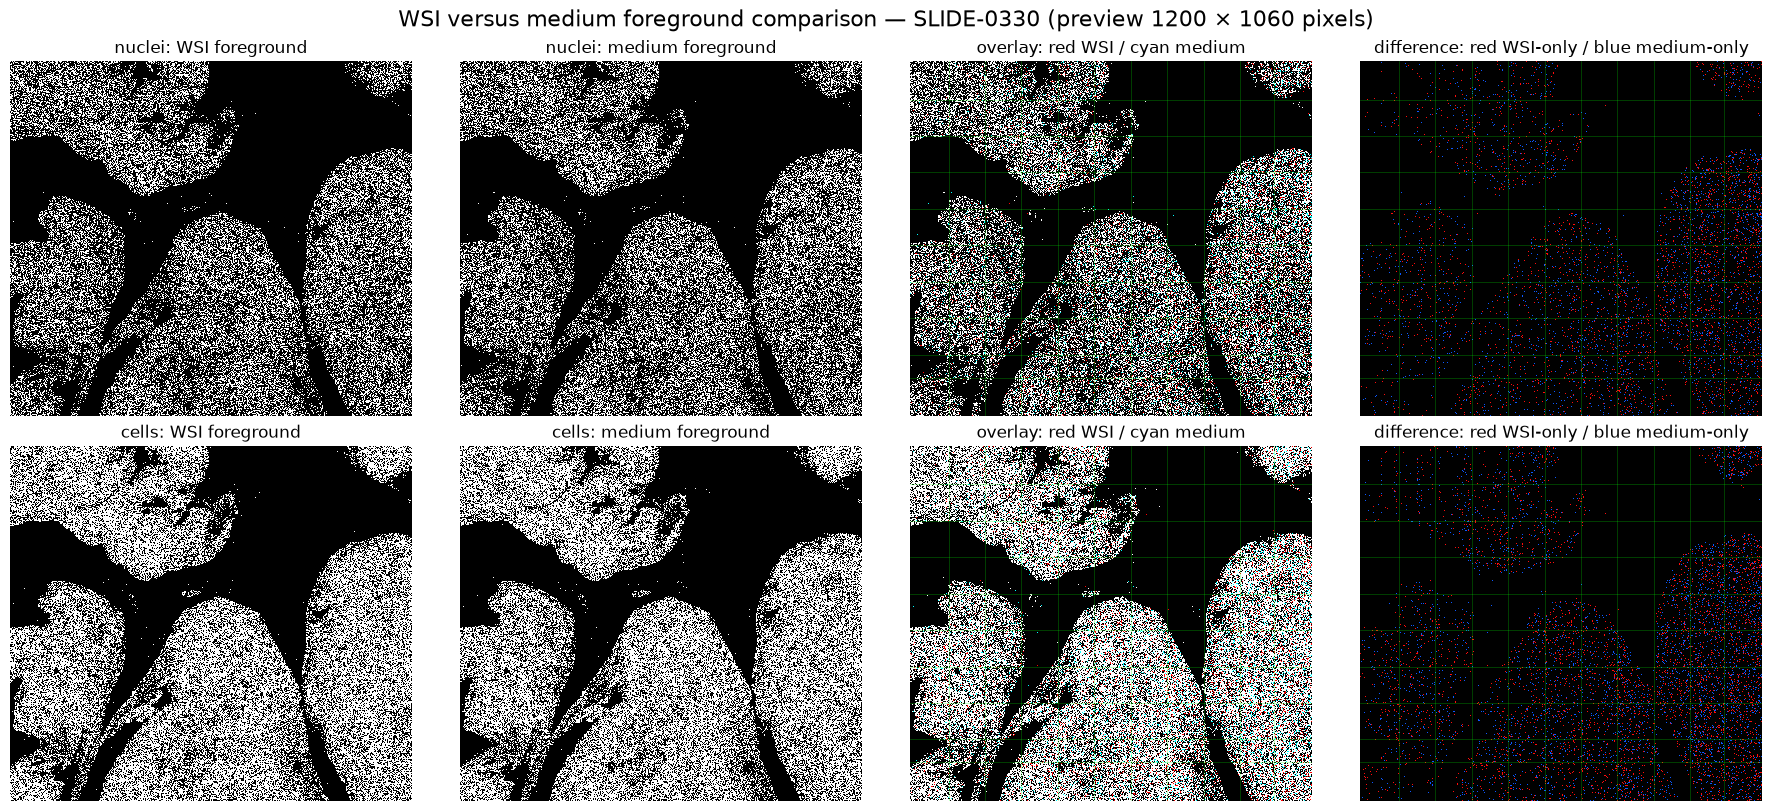

In [7]:
# Display a bounded preview of the comparison without loading either full label image.
import matplotlib.pyplot as plt

VISUAL_MAX_DIM = 1200
VISUAL_ROW_BLOCK = 128

comparison = json.loads(COMPARISON_JSON.read_text())
wsi_preview_store = zarr.open(comparison['wsi'], mode='r')
medium_preview_store = zarr.open(comparison['medium'], mode='r')

def read_label_preview(wsi_store, medium_store, plane, max_dim=VISUAL_MAX_DIM):
    model_height, model_width = (int(value) for value in wsi_store.shape[-2:])
    native_height, native_width = (int(value) for value in medium_store.shape[-2:])
    scale = min(1.0, max_dim / max(native_height, native_width))
    preview_height = max(1, int(round(native_height * scale)))
    preview_width = max(1, int(round(native_width * scale)))

    native_y = np.linspace(0, native_height - 1, preview_height, dtype=np.int64)
    native_x = np.linspace(0, native_width - 1, preview_width, dtype=np.int64)
    model_y = np.minimum(native_y * model_height // native_height, model_height - 1)
    model_x = np.minimum(native_x * model_width // native_width, model_width - 1)

    wsi_preview = np.empty((preview_height, preview_width), dtype=np.int32)
    medium_preview = np.empty((preview_height, preview_width), dtype=np.int32)
    for row_start in range(0, preview_height, VISUAL_ROW_BLOCK):
        row_stop = min(preview_height, row_start + VISUAL_ROW_BLOCK)

        medium_rows = native_y[row_start:row_stop]
        medium_y0, medium_y1 = int(medium_rows.min()), int(medium_rows.max()) + 1
        medium_block = np.asarray(medium_store[plane, medium_y0:medium_y1, :])
        medium_preview[row_start:row_stop] = np.take(
            np.take(medium_block, medium_rows - medium_y0, axis=0),
            native_x, axis=1,
        )

        model_rows = model_y[row_start:row_stop]
        model_y0, model_y1 = int(model_rows.min()), int(model_rows.max()) + 1
        wsi_block = np.asarray(wsi_store[plane, model_y0:model_y1, :])
        wsi_preview[row_start:row_stop] = np.take(
            np.take(wsi_block, model_rows - model_y0, axis=0),
            model_x, axis=1,
        )

    return wsi_preview, medium_preview, (native_height, native_width)

plane_names = ['nuclei', 'cells'][:int(wsi_preview_store.shape[0])]
fig, axes = plt.subplots(
    len(plane_names), 4, figsize=(18, 8 * len(plane_names) / 2),
    squeeze=False, constrained_layout=True,
)

for plane, plane_name in enumerate(plane_names):
    wsi_labels, medium_labels, native_shape = read_label_preview(
        wsi_preview_store, medium_preview_store, plane,
    )
    wsi_foreground = wsi_labels > 0
    medium_foreground = medium_labels > 0
    wsi_only = wsi_foreground & ~medium_foreground
    medium_only = medium_foreground & ~wsi_foreground

    overlay = np.zeros((*wsi_foreground.shape, 3), dtype=np.float32)
    overlay[..., 0] = wsi_foreground
    overlay[..., 1] = medium_foreground
    overlay[..., 2] = medium_foreground
    difference = np.zeros_like(overlay)
    difference[wsi_only] = (1.0, 0.05, 0.05)
    difference[medium_only] = (0.05, 0.35, 1.0)

    images = (wsi_foreground, medium_foreground, overlay, difference)
    cmaps = ('gray', 'gray', None, None)
    titles = (
        f'{plane_name}: WSI foreground',
        f'{plane_name}: medium foreground',
        'overlay: red WSI / cyan medium',
        'difference: red WSI-only / blue medium-only',
    )
    for column, (image, cmap, title) in enumerate(zip(images, cmaps, titles)):
        axes[plane, column].imshow(image, cmap=cmap, interpolation='nearest')
        axes[plane, column].set_title(title)
        axes[plane, column].set_axis_off()

    report = comparison['planes'][plane]
    axes[plane, 2].set_xlabel(
        f"foreground IoU={report['foreground']['foreground_iou']:.4f}; objects matched={report['foreground']['object_comparison']['wsi_object_match_fraction']:.3%}",
        labelpad=8,
    )
    axes[plane, 3].set_xlabel(
        f"{int(wsi_only.sum()):,} WSI-only; {int(medium_only.sum()):,} medium-only preview pixels",
        labelpad=8,
    )

    seam_x = _native_tile_seam_positions(wsi_preview_store.shape[-1], native_shape[1])
    seam_y = _native_tile_seam_positions(wsi_preview_store.shape[-2], native_shape[0])
    preview_height, preview_width = wsi_foreground.shape
    for axis in (axes[plane, 2], axes[plane, 3]):
        for position in seam_x:
            axis.axvline(position * preview_width / native_shape[1], color='lime', alpha=0.35, linewidth=0.5)
        for position in seam_y:
            axis.axhline(position * preview_height / native_shape[0], color='lime', alpha=0.35, linewidth=0.5)

fig.suptitle(
    f"WSI versus medium foreground comparison — {SLIDE_ID} (preview {wsi_foreground.shape[1]} × {wsi_foreground.shape[0]} pixels)",
    fontsize=16,
)
plt.show()
del wsi_preview_store, medium_preview_store


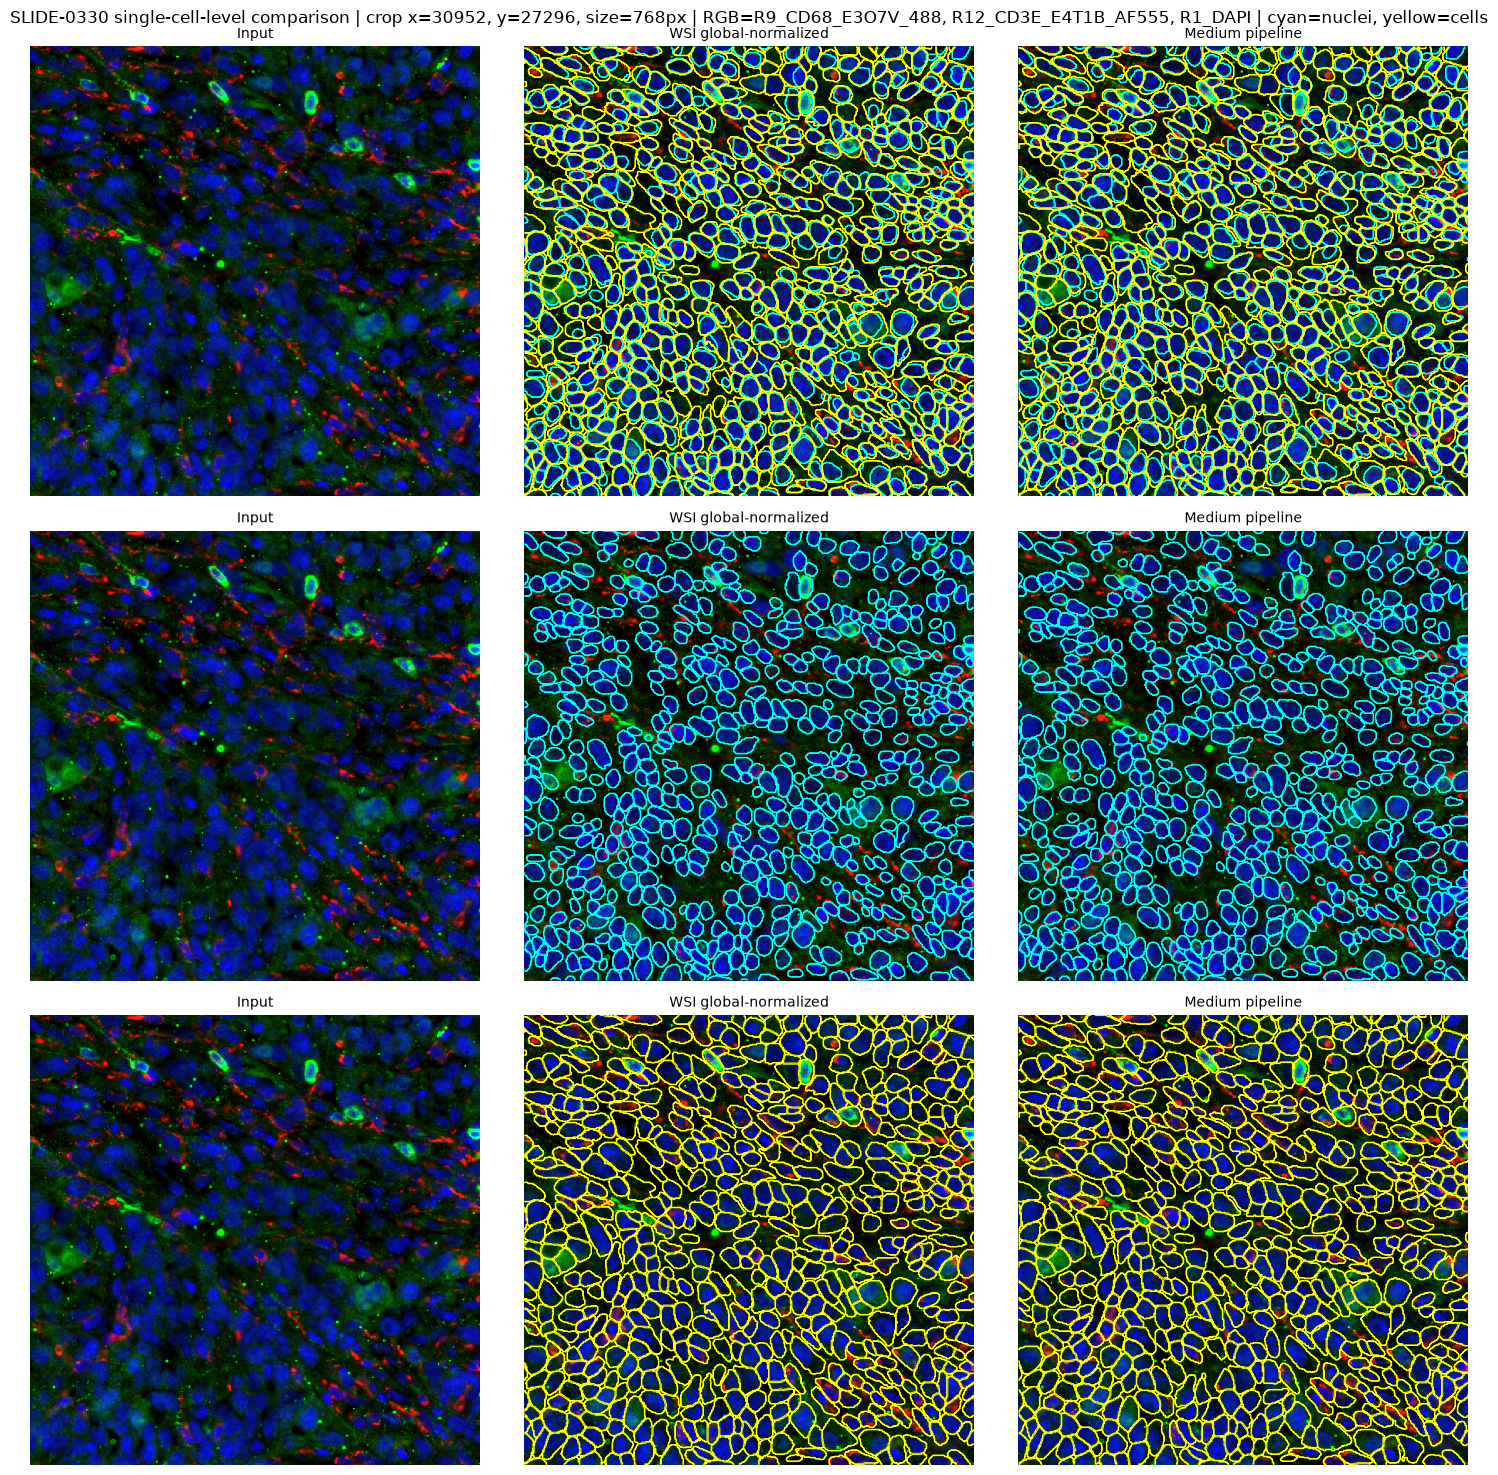

{'zoom_native_shape': (768, 768), 'zoom_crop_coordinates': (30952, 27296), 'wsi_model_shape': (768, 768), 'display_channels_rgb': ['R9_CD68_E3O7V_488', 'R12_CD3E_E4T1B_AF555', 'R1_DAPI']}


In [8]:
# Show one native-resolution crop with the input image and both mask boundaries.
# Change ZOOM_X/ZOOM_Y to inspect another area; no inference is rerun here.
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries

ZOOM_SIZE = 768
ZOOM_X = max(0, (CROP_WIDTH - ZOOM_SIZE) // 2)
ZOOM_Y = max(0, (CROP_HEIGHT - ZOOM_SIZE) // 2)
DISPLAY_CHANNELS = ['R9_CD68_E3O7V_488', 'R12_CD3E_E4T1B_AF555', 'R1_DAPI']
DISPLAY_CHANNEL_IDS = [SEGMENTATION_CHANNELS.index(name) for name in DISPLAY_CHANNELS]
if ZOOM_X + ZOOM_SIZE > CROP_WIDTH or ZOOM_Y + ZOOM_SIZE > CROP_HEIGHT:
    raise ValueError('The requested zoom does not fit inside the crop.')

# Read only the three display channels from the selected-channel crop.
with tifffile.TiffFile(str(CROP_OME)) as handle:
    input_store = handle.series[0].aszarr(level=0)
    try:
        input_array = zarr.open(input_store, mode='r')
        input_zoom = np.asarray(input_array.oindex[
            DISPLAY_CHANNEL_IDS,
            slice(ZOOM_Y, ZOOM_Y + ZOOM_SIZE),
            slice(ZOOM_X, ZOOM_X + ZOOM_SIZE),
        ])
    finally:
        input_store.close()

wsi_zoom_store = zarr.open(comparison['wsi'], mode='r')
medium_zoom_store = zarr.open(comparison['medium'], mode='r')
model_height, model_width = (int(value) for value in wsi_zoom_store.shape[-2:])
native_height, native_width = (int(value) for value in medium_zoom_store.shape[-2:])
native_y = np.arange(ZOOM_Y, ZOOM_Y + ZOOM_SIZE, dtype=np.int64)
native_x = np.arange(ZOOM_X, ZOOM_X + ZOOM_SIZE, dtype=np.int64)
model_y = np.minimum(native_y * model_height // native_height, model_height - 1)
model_x = np.minimum(native_x * model_width // native_width, model_width - 1)

wsi_zoom = np.empty((int(wsi_zoom_store.shape[0]), ZOOM_SIZE, ZOOM_SIZE), dtype=np.int32)
for plane in range(wsi_zoom.shape[0]):
    model_y0, model_y1 = int(model_y.min()), int(model_y.max()) + 1
    model_block = np.asarray(wsi_zoom_store[plane, model_y0:model_y1, :])
    wsi_zoom[plane] = np.take(
        np.take(model_block, model_y - model_y0, axis=0),
        model_x, axis=1,
    )
medium_zoom = np.asarray(medium_zoom_store[:, ZOOM_Y:ZOOM_Y + ZOOM_SIZE, ZOOM_X:ZOOM_X + ZOOM_SIZE])

def robust01_zoom(image, percentiles=(1.0, 99.8)):
    image = np.asarray(image, dtype=np.float32)
    low, high = np.percentile(image, percentiles)
    if high <= low:
        return np.zeros_like(image, dtype=np.float32)
    return np.clip((image - low) / (high - low), 0, 1)

rgb_zoom = np.stack([robust01_zoom(channel) for channel in input_zoom], axis=-1)

def show_zoom_prediction(axis, labels, mode, title):
    axis.imshow(rgb_zoom, interpolation='nearest')
    if mode in ('both', 'nuclei'):
        axis.contour(find_boundaries(labels[0], mode='outer'), levels=[0.5], colors=['cyan'], linewidths=0.7)
    if mode in ('both', 'cells'):
        axis.contour(find_boundaries(labels[1], mode='outer'), levels=[0.5], colors=['yellow'], linewidths=0.7)
    axis.set_title(title, fontsize=10)
    axis.axis('off')

fig, axes = plt.subplots(3, 3, figsize=(15, 15), squeeze=False)
for row, mode in enumerate(('both', 'nuclei', 'cells')):
    axes[row, 0].imshow(rgb_zoom, interpolation='nearest')
    axes[row, 0].set_title('Input', fontsize=10)
    axes[row, 0].set_ylabel(mode.title(), fontsize=11)
    axes[row, 0].axis('off')
    show_zoom_prediction(axes[row, 1], wsi_zoom, mode, 'WSI global-normalized')
    show_zoom_prediction(axes[row, 2], medium_zoom, mode, 'Medium pipeline')
fig.suptitle(
    f'{SLIDE_ID} single-cell-level comparison | crop x={CROP_X + ZOOM_X}, y={CROP_Y + ZOOM_Y}, size={ZOOM_SIZE}px | '
    f'RGB={DISPLAY_CHANNELS[0]}, {DISPLAY_CHANNELS[1]}, {DISPLAY_CHANNELS[2]} | cyan=nuclei, yellow=cells',
    fontsize=12,
)
fig.tight_layout()
plt.show()
print({
    'zoom_native_shape': (ZOOM_SIZE, ZOOM_SIZE),
    'zoom_crop_coordinates': (CROP_X + ZOOM_X, CROP_Y + ZOOM_Y),
    'wsi_model_shape': (int(wsi_zoom.shape[-2]), int(wsi_zoom.shape[-1])),
    'display_channels_rgb': DISPLAY_CHANNELS,
})
del wsi_zoom_store, medium_zoom_store, input_zoom, wsi_zoom, medium_zoom, rgb_zoom
